# Cell-Type-Gated Correlation: Building GEP Trees Across K Values

**Prerequisite:** Run `gsea_celltype_annotation.ipynb` first to generate NES CSVs.

**Problem:** Naive correlation of all GEPs at K with all GEPs at K+1 conflates programs from different cell types, producing spurious cross-cell-type edges.

**Solution:** Cell-type-gated similarity with two modes:
1. **Hard gating** — only allow parent→child edges within the same top cell type
2. **Soft gating** — weight similarity by cell-type agreement using KL divergence of cell-type usage distributions

**Similarity backbone:** Spearman correlation of NES profile vectors (GEP × cell type), optionally supplemented by usage-based correlation.

**Output:** An edge list defining the GEP tree across K values, plus visualizations.

In [1]:
import os
import glob
import re
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from scipy.spatial.distance import cosine as cosine_dist
from scipy.special import rel_entr  # for KL divergence
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

## 1. Configuration

Update these to match your paths from the upstream notebooks.

In [2]:
# ──────────────────────────────────────────────────
# Paths
# ──────────────────────────────────────────────────
GSEA_DIR = "gsea_celltype_results"        # Directory with NES_k*.csv files
CNMF_DIR = "cnmf_results_S1_k3-30"       # Directory with cNMF outputs
CNMF_PREFIX = "anal_pc5_c21_S1.filtered"  # cNMF run name prefix
DENSITY_THRESHOLD = "0_01"                # Density threshold string in filenames

OUTPUT_DIR = "celltype_gated_correlation_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ──────────────────────────────────────────────────
# K range
# ──────────────────────────────────────────────────
K_MIN = 5
K_MAX = 21

# ──────────────────────────────────────────────────
# Gating mode: "hard" or "soft"
# ──────────────────────────────────────────────────
GATING_MODE = "soft"  # "hard" = strict same-cell-type only; "soft" = KL-penalized

# ──────────────────────────────────────────────────
# Similarity metric for the backbone
# ──────────────────────────────────────────────────
# "nes_spearman"  — Spearman correlation of NES profile vectors
# "usage_spearman" — Spearman correlation of usage vectors (cells in common)
SIMILARITY_METRIC = "nes_spearman"

# ──────────────────────────────────────────────────
# Soft gating parameters
# ──────────────────────────────────────────────────
LAMBDA_KL = 0.5       # Penalty strength: higher = stricter gating
                       # 0.0 = no penalty (pure similarity)
                       # 1.0 = strong penalty for cell-type mismatch
EPSILON = 1e-8         # Small constant to avoid log(0) in KL divergence

# ──────────────────────────────────────────────────
# Edge selection
# ──────────────────────────────────────────────────
# For each child GEP at K+1, pick the best parent at K.
# Additionally, a parent can have multiple children (splitting).
MIN_SIMILARITY = 0.3   # Minimum (gated) similarity to form an edge

print(f"Gating mode: {GATING_MODE}")
print(f"Similarity metric: {SIMILARITY_METRIC}")
print(f"Lambda (KL penalty): {LAMBDA_KL}")
print(f"Min similarity threshold: {MIN_SIMILARITY}")
print(f"K range: {K_MIN}–{K_MAX}")

Gating mode: soft
Similarity metric: nes_spearman
Lambda (KL penalty): 0.5
Min similarity threshold: 0.3
K range: 5–21


## 2. Load NES Scores and Usage Matrices

In [3]:
all_nes = {}   # k -> DataFrame (GEPs × cell types)
k_values = []

for f in sorted(glob.glob(os.path.join(GSEA_DIR, "NES_k*.csv"))):
    match = re.search(r'NES_k(\d+)\.csv', os.path.basename(f))
    if match:
        k = int(match.group(1))
        if K_MIN <= k <= K_MAX:
            df = pd.read_csv(f, index_col=0)
            all_nes[k] = df
            k_values.append(k)

k_values = sorted(k_values)
print(f"Loaded NES for {len(k_values)} K values: {k_values}")
for k in k_values:
    print(f"  K={k}: {all_nes[k].shape[0]} GEPs × {all_nes[k].shape[1]} cell types")

Loaded NES for 17 K values: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
  K=5: 5 GEPs × 17 cell types
  K=6: 6 GEPs × 17 cell types
  K=7: 7 GEPs × 17 cell types
  K=8: 8 GEPs × 17 cell types
  K=9: 9 GEPs × 17 cell types
  K=10: 10 GEPs × 17 cell types
  K=11: 11 GEPs × 17 cell types
  K=12: 12 GEPs × 17 cell types
  K=13: 13 GEPs × 17 cell types
  K=14: 14 GEPs × 17 cell types
  K=15: 15 GEPs × 17 cell types
  K=16: 16 GEPs × 17 cell types
  K=17: 17 GEPs × 17 cell types
  K=18: 18 GEPs × 17 cell types
  K=19: 19 GEPs × 17 cell types
  K=20: 20 GEPs × 17 cell types
  K=21: 21 GEPs × 17 cell types


In [4]:
# ── Load usage matrices (needed if SIMILARITY_METRIC == "usage_spearman") ──
all_usage = {}  # k -> DataFrame (cells × GEPs)

if SIMILARITY_METRIC == "usage_spearman":
    for k in k_values:
        usage_path = os.path.join(
            CNMF_DIR,
            f"{CNMF_PREFIX}.usages.k_{k}.dt_{DENSITY_THRESHOLD}.consensus.txt"
        )
        if os.path.exists(usage_path):
            all_usage[k] = pd.read_csv(usage_path, sep='\t', index_col=0)
            all_usage[k].index = all_usage[k].index.astype(str)
        else:
            print(f"  WARNING: usage file not found for K={k}: {usage_path}")
    print(f"Loaded usage matrices for {len(all_usage)} K values")
else:
    print("Usage matrices not needed for NES-based similarity.")

Usage matrices not needed for NES-based similarity.


## 3. Helper Functions

In [5]:
def nes_to_distribution(nes_row, epsilon=EPSILON):
    """
    Convert a NES score vector into a proper probability distribution
    for KL divergence computation.
    
    Uses softmax of positive NES values (negative NES → near-zero probability).
    """
    # Shift so that NES=0 maps to 0, positive NES gets weight
    # Use ReLU + softmax: only positive enrichments contribute
    vals = np.maximum(nes_row.values.astype(float), 0.0)
    
    if vals.sum() == 0:
        # No positive enrichment — return uniform
        return np.ones(len(vals)) / len(vals)
    
    # Normalize to probability distribution
    dist = vals / vals.sum()
    # Add epsilon for numerical stability, then renormalize
    dist = dist + epsilon
    dist = dist / dist.sum()
    return dist


def symmetric_kl(p, q):
    """
    Symmetric KL divergence (Jensen-Shannon style average of KL(P||Q) and KL(Q||P)).
    """
    kl_pq = np.sum(rel_entr(p, q))
    kl_qp = np.sum(rel_entr(q, p))
    return 0.5 * (kl_pq + kl_qp)


def compute_backbone_similarity(nes_parent, nes_child, usage_parent=None, usage_child=None,
                                 metric="nes_spearman"):
    """
    Compute the raw (un-gated) similarity between a parent GEP and a child GEP.
    
    Parameters
    ----------
    nes_parent, nes_child : pd.Series
        NES score vectors (indexed by cell type). Must share the same index.
    usage_parent, usage_child : pd.Series or None
        Usage vectors (indexed by cell barcode). Only needed for usage_spearman.
    metric : str
        One of 'nes_spearman', 'usage_spearman'.
    
    Returns
    -------
    float : similarity in [−1, 1] for correlations, [0, 1] for cosine.
    """
    if metric == "nes_spearman":
        # Align cell types
        common = nes_parent.index.intersection(nes_child.index)
        if len(common) < 3:
            return 0.0
        rho, _ = spearmanr(nes_parent[common].values, nes_child[common].values)
        return rho if not np.isnan(rho) else 0.0 
    elif metric == "usage_spearman":
        if usage_parent is None or usage_child is None:
            raise ValueError("usage_spearman requires usage vectors")
        common_cells = usage_parent.index.intersection(usage_child.index)
        if len(common_cells) < 10:
            return 0.0
        rho, _ = spearmanr(
            usage_parent[common_cells].values,
            usage_child[common_cells].values
        )
        return rho if not np.isnan(rho) else 0.0
    else:
        raise ValueError(f"Unknown metric: {metric}")


def compute_gated_similarity(nes_parent, nes_child,
                              usage_parent=None, usage_child=None,
                              metric="nes_spearman",
                              gating="soft",
                              lambda_kl=0.5, epsilon=1e-8):
    """
    Compute cell-type-gated similarity between a parent and child GEP.
    
    Parameters
    ----------
    gating : str
        'hard' — returns 0.0 if top cell types disagree, raw sim otherwise.
        'soft' — multiplies raw sim by exp(-lambda * KL_divergence).
        'none' — no gating, returns raw similarity.
    
    Returns
    -------
    dict with keys:
        'gated_sim' : float — final gated similarity
        'raw_sim' : float — backbone similarity before gating
        'kl_div' : float — symmetric KL divergence (NaN for hard gating)
        'penalty' : float — gating penalty multiplier
        'parent_celltype' : str — top cell type of parent
        'child_celltype' : str — top cell type of child
        'celltype_match' : bool — whether top cell types agree
    """
    # Align cell types
    common_ct = nes_parent.index.intersection(nes_child.index)
    p_aligned = nes_parent[common_ct]
    c_aligned = nes_child[common_ct]
    # Top cell types
    parent_ct = p_aligned.idxmax()
    child_ct = c_aligned.idxmax()
    ct_match = (parent_ct == child_ct)
    
    # Raw backbone similarity
    raw_sim = compute_backbone_similarity(
        nes_parent, nes_child, usage_parent, usage_child, metric
    )
    
    if gating == "hard":
        penalty = 1.0 if ct_match else 0.0
        return {
            'gated_sim': raw_sim * penalty,
            'raw_sim': raw_sim,
            'kl_div': np.nan,
            'penalty': penalty,
            'parent_celltype': parent_ct,
            'child_celltype': child_ct,
            'celltype_match': ct_match
        }
    
    elif gating == "soft":
        # Convert NES profiles to distributions
        p_dist = nes_to_distribution(p_aligned, epsilon)
        c_dist = nes_to_distribution(c_aligned, epsilon)
        
        # Symmetric KL divergence
        kl = symmetric_kl(p_dist, c_dist)
        
        # Penalty
        penalty = np.exp(-lambda_kl * kl)
        
        return {
            'gated_sim': raw_sim * penalty,
            'raw_sim': raw_sim,
            'kl_div': kl,
            'penalty': penalty,
            'parent_celltype': parent_ct,
            'child_celltype': child_ct,
            'celltype_match': ct_match
        }
    
    else:
        raise ValueError(f"Unknown gating mode: {gating}")

## 4. Compute All Pairwise Gated Similarities Across Consecutive K Values

In [6]:
# For each consecutive (K, K+1) pair, compute the full similarity matrix
# between all parent GEPs at K and all child GEPs at K+1.

all_sim_matrices = {}   # (k_parent, k_child) -> DataFrame
all_detail_records = [] # list of dicts for detailed inspection

for i in range(len(k_values) - 1):
    k_parent = k_values[i]
    k_child = k_values[i + 1]
    
    nes_p = all_nes[k_parent]  # (n_geps_parent × cell_types)
    nes_c = all_nes[k_child]   # (n_geps_child  × cell_types)
    
    # Usage matrices (if needed)
    usage_p_df = all_usage.get(k_parent)
    usage_c_df = all_usage.get(k_child)
    
    sim_matrix = pd.DataFrame(
        index=nes_p.index,
        columns=nes_c.index,
        dtype=float
    )
    
    for parent_gep in nes_p.index:
        for child_gep in nes_c.index:
            # Get usage vectors if needed
            u_p = usage_p_df[parent_gep] if usage_p_df is not None else None
            u_c = usage_c_df[child_gep] if usage_c_df is not None else None
            
            result = compute_gated_similarity(
                nes_parent=nes_p.loc[parent_gep],
                nes_child=nes_c.loc[child_gep],
                usage_parent=u_p,
                usage_child=u_c,
                metric=SIMILARITY_METRIC,
                gating=GATING_MODE,
                lambda_kl=LAMBDA_KL,
                epsilon=EPSILON
            )
            
            sim_matrix.loc[parent_gep, child_gep] = result['gated_sim']
            
            # Store detailed record
            all_detail_records.append({
                'k_parent': k_parent,
                'k_child': k_child,
                'parent_gep': parent_gep,
                'child_gep': child_gep,
                'raw_sim': result['raw_sim'],
                'kl_div': result['kl_div'],
                'penalty': result['penalty'],
                'gated_sim': result['gated_sim'],
                'parent_celltype': result['parent_celltype'],
                'child_celltype': result['child_celltype'],
                'celltype_match': result['celltype_match']
            })
    
    all_sim_matrices[(k_parent, k_child)] = sim_matrix
    
    print(f"K={k_parent} → K={k_child}: "
          f"{sim_matrix.shape[0]} parents × {sim_matrix.shape[1]} children, "
          f"max gated sim = {sim_matrix.values.max():.3f}")

details_df = pd.DataFrame(all_detail_records)
print(f"\nTotal pairwise comparisons: {len(details_df)}")

K=5 → K=6: 5 parents × 6 children, max gated sim = 1.000
K=6 → K=7: 6 parents × 7 children, max gated sim = 0.995
K=7 → K=8: 7 parents × 8 children, max gated sim = 0.985
K=8 → K=9: 8 parents × 9 children, max gated sim = 1.000
K=9 → K=10: 9 parents × 10 children, max gated sim = 0.999
K=10 → K=11: 10 parents × 11 children, max gated sim = 1.000
K=11 → K=12: 11 parents × 12 children, max gated sim = 0.967
K=12 → K=13: 12 parents × 13 children, max gated sim = 0.973
K=13 → K=14: 13 parents × 14 children, max gated sim = 1.000
K=14 → K=15: 14 parents × 15 children, max gated sim = 1.000
K=15 → K=16: 15 parents × 16 children, max gated sim = 0.981
K=16 → K=17: 16 parents × 17 children, max gated sim = 0.985
K=17 → K=18: 17 parents × 18 children, max gated sim = 0.953
K=18 → K=19: 18 parents × 19 children, max gated sim = 1.000
K=19 → K=20: 19 parents × 20 children, max gated sim = 0.998
K=20 → K=21: 20 parents × 21 children, max gated sim = 0.985

Total pairwise comparisons: 3040


## 5. Build the Edge List (Parent → Child Assignments)

**Strategy:** For each child GEP at K+1, assign the best parent at K (greedy best-match-per-child). A parent can have 0, 1, or many children (supporting splits). Children with no parent above `MIN_SIMILARITY` are flagged as "novel" (de novo emergence).

In [7]:
edges = []

for (k_parent, k_child), sim_matrix in sorted(all_sim_matrices.items()):
    for child_gep in sim_matrix.columns:
        # Best parent for this child
        best_parent = sim_matrix[child_gep].idxmax()
        best_sim = sim_matrix[child_gep].max()
        
        if best_sim >= MIN_SIMILARITY:
            # Look up cell types
            parent_ct = all_nes[k_parent].loc[best_parent].idxmax()
            child_ct = all_nes[k_child].loc[child_gep].idxmax()
            
            edges.append({
                'k_parent': k_parent,
                'k_child': k_child,
                'parent_gep': best_parent,
                'child_gep': child_gep,
                'gated_similarity': round(best_sim, 4),
                'parent_celltype': parent_ct,
                'child_celltype': child_ct,
                'celltype_match': parent_ct == child_ct
            })
        else:
            child_ct = all_nes[k_child].loc[child_gep].idxmax()
            edges.append({
                'k_parent': k_parent,
                'k_child': k_child,
                'parent_gep': None,
                'child_gep': child_gep,
                'gated_similarity': round(best_sim, 4),
                'parent_celltype': None,
                'child_celltype': child_ct,
                'celltype_match': False
            })

edges_df = pd.DataFrame(edges)

# Summary
n_connected = edges_df['parent_gep'].notna().sum()
n_novel = edges_df['parent_gep'].isna().sum()
n_ct_match = edges_df.loc[edges_df['parent_gep'].notna(), 'celltype_match'].sum()

print(f"Total edges: {len(edges_df)}")
print(f"  Connected (parent assigned): {n_connected}")
print(f"  Novel (no parent above threshold): {n_novel}")
print(f"  Cell-type-matching edges: {n_ct_match}/{n_connected} "
      f"({100*n_ct_match/max(n_connected,1):.1f}%)")

# Save
edges_path = os.path.join(OUTPUT_DIR, "gep_tree_edges.csv")
edges_df.to_csv(edges_path, index=False)
print(f"\nEdge list saved to: {edges_path}")
edges_df.head(10)

Total edges: 216
  Connected (parent assigned): 211
  Novel (no parent above threshold): 5
  Cell-type-matching edges: 161/211 (76.3%)

Edge list saved to: celltype_gated_correlation_results/gep_tree_edges.csv


,k_parent,k_child,parent_gep,child_gep,gated_similarity,parent_celltype,child_celltype,celltype_match
0,5,6,1.0,1,0.9975,CD4+Tcells,CD4+Tcells,True
1,5,6,2.0,2,0.9972,Tumor/Epithelials,Tumor/Epithelials,True
2,5,6,3.0,3,0.9969,Tumor/Epithelials,Tumor/Epithelials,True
3,5,6,4.0,4,0.9975,Fibroblasts/Stromal,Fibroblasts/Stromal,True
4,5,6,5.0,5,1.0000,Mac_C1Q_ZEB2,Mac_C1Q_ZEB2,True
5,5,6,5.0,6,0.3725,Mac_C1Q_ZEB2,CD8+Tcells_Ki67,False
6,6,7,1.0,1,0.9946,CD4+Tcells,CD4+Tcells,True
7,6,7,2.0,2,0.9881,Tumor/Epithelials,Tumor/Epithelials,True
8,6,7,2.0,3,0.7091,Tumor/Epithelials,Tumor/Epithelials,True
9,6,7,6.0,4,0.7070,CD8+Tcells_Ki67,Fibroblasts/Stromal,False


## 6. Identify Splits and Merges

- **Split:** A parent at K maps to 2+ children at K+1
- **Merge:** A child at K+1 is the best match for 2+ parents at K (rare with best-match-per-child, but detectable)

In [8]:
connected_edges = edges_df[edges_df['parent_gep'].notna()].copy()

# Splits: parents with multiple children
splits = connected_edges.groupby(['k_parent', 'parent_gep']).agg(
    n_children=('child_gep', 'count'),
    children=('child_gep', list),
    child_celltypes=('child_celltype', list)
).reset_index()
splits = splits[splits['n_children'] > 1].sort_values('n_children', ascending=False)

print(f"Splitting events (parent with 2+ children):")
print(f"{'='*70}")
if len(splits) == 0:
    print("  None detected.")
else:
    for _, row in splits.iterrows():
        parent_ct = all_nes[row['k_parent']].loc[row['parent_gep']].idxmax()
        child_cts = row['child_celltypes']
        same_ct = all(ct == parent_ct for ct in child_cts)
        tag = "same cell type" if same_ct else "CROSS cell type"
        print(f"  K={row['k_parent']} {row['parent_gep']} ({parent_ct}) → "
              f"{row['n_children']} children: {row['children']} [{tag}]")
        for child, ct in zip(row['children'], child_cts):
            print(f"    └─ {child} ({ct})")

# Novel programs (de novo at K+1)
novel = edges_df[edges_df['parent_gep'].isna()]
print(f"\nNovel programs (no parent above threshold):")
print(f"{'='*70}")
if len(novel) == 0:
    print("  None.")
else:
    for _, row in novel.iterrows():
        print(f"  K={row['k_child']} {row['child_gep']} ({row['child_celltype']}) "
              f"— best sim was {row['gated_similarity']:.3f}")

Splitting events (parent with 2+ children):
  K=19 17.0 (Tumor/Epithelials) → 5 children: [5, 12, 15, 19, 20] [CROSS cell type]
    └─ 5 (Tumor/Epithelials)
    └─ 12 (Tumor/Epithelials)
    └─ 15 (DC_LAMP3)
    └─ 19 (Mast)
    └─ 20 (Mon_VCAN)
  K=19 8.0 (Endothelials) → 5 children: [7, 10, 11, 16, 18] [CROSS cell type]
    └─ 7 (Tumor/Epithelials)
    └─ 10 (CD8+Tcells_Ki67)
    └─ 11 (Endothelials)
    └─ 16 (CD8+Tcells_Ki67)
    └─ 18 (DC_LAMP3)
  K=20 9.0 (Mac_C1Q_SPP1) → 4 children: [5, 8, 15, 17] [CROSS cell type]
    └─ 5 (Bcells_CD19)
    └─ 8 (Fibroblasts/Stromal)
    └─ 15 (Plasma_XBP1)
    └─ 17 (Mac_C1Q_SPP1)
  K=12 7.0 (Fibroblasts/Stromal) → 3 children: [7, 10, 12] [CROSS cell type]
    └─ 7 (Fibroblasts/Stromal)
    └─ 10 (CD8+Tcells_Ki67)
    └─ 12 (Fibroblasts/Stromal)
  K=6 6.0 (CD8+Tcells_Ki67) → 3 children: [4, 6, 7] [CROSS cell type]
    └─ 4 (Fibroblasts/Stromal)
    └─ 6 (Endothelials)
    └─ 7 (Tumor/Epithelials)
  K=20 7.0 (Tumor/Epithelials) → 3 children: [1

## 7. Visualizations

### 7a. Heatmaps: Gated Similarity Matrices per K→K+1 Transition

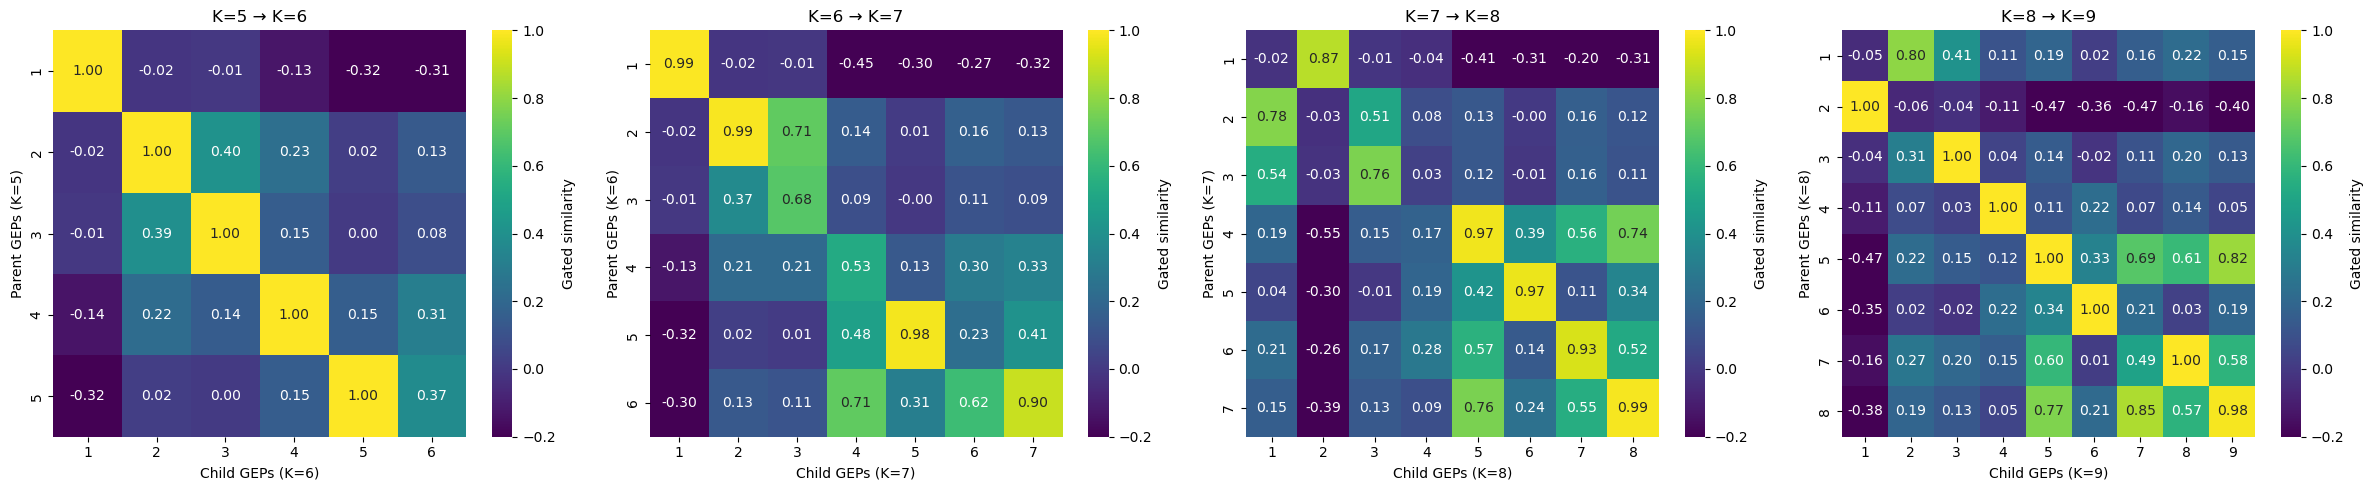

In [9]:
# Plot similarity heatmaps for a few transitions
transitions_to_plot = list(all_sim_matrices.keys())[:4]  # first 4

fig, axes = plt.subplots(1, len(transitions_to_plot),
                         figsize=(6 * len(transitions_to_plot), 5))
if len(transitions_to_plot) == 1:
    axes = [axes]

for ax, (k_p, k_c) in zip(axes, transitions_to_plot):
    sim = all_sim_matrices[(k_p, k_c)].astype(float)
    sns.heatmap(sim, cmap='viridis', annot=sim.shape[0] <= 12,
                fmt='.2f' if sim.shape[0] <= 12 else '',
                ax=ax, vmin=-0.2, vmax=1.0,
                cbar_kws={'label': 'Gated similarity'})
    ax.set_title(f'K={k_p} → K={k_c}', fontsize=12)
    ax.set_xlabel(f'Child GEPs (K={k_c})')
    ax.set_ylabel(f'Parent GEPs (K={k_p})')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "similarity_heatmaps.png"), dpi=150, bbox_inches='tight')
plt.show()

### 7b. GEP Tree Diagram

A layered graph showing GEPs at each K level connected by parent→child edges. Nodes are colored by their top cell type.

In [10]:
# Assign a color to each cell type
all_celltypes = set()
for k in k_values:
    for gep in all_nes[k].index:
        all_celltypes.add(all_nes[k].loc[gep].idxmax())
all_celltypes = sorted(all_celltypes)

cmap = plt.cm.get_cmap('tab20', len(all_celltypes))
ct_colors = {ct: cmap(i) for i, ct in enumerate(all_celltypes)}

print(f"Cell types in tree: {len(all_celltypes)}")
for ct, color in ct_colors.items():
    print(f"  {ct}")

Cell types in tree: 14
  Bcells_CD19
  CD4+Tcells
  CD8+Tcells
  CD8+Tcells_Ki67
  DC_LAMP3
  Endothelials
  Fibroblasts/Stromal
  Mac_C1Q_SPP1
  Mac_C1Q_ZEB2
  Mast
  Mon_VCAN
  Plasma_XBP1
  Tregs
  Tumor/Epithelials


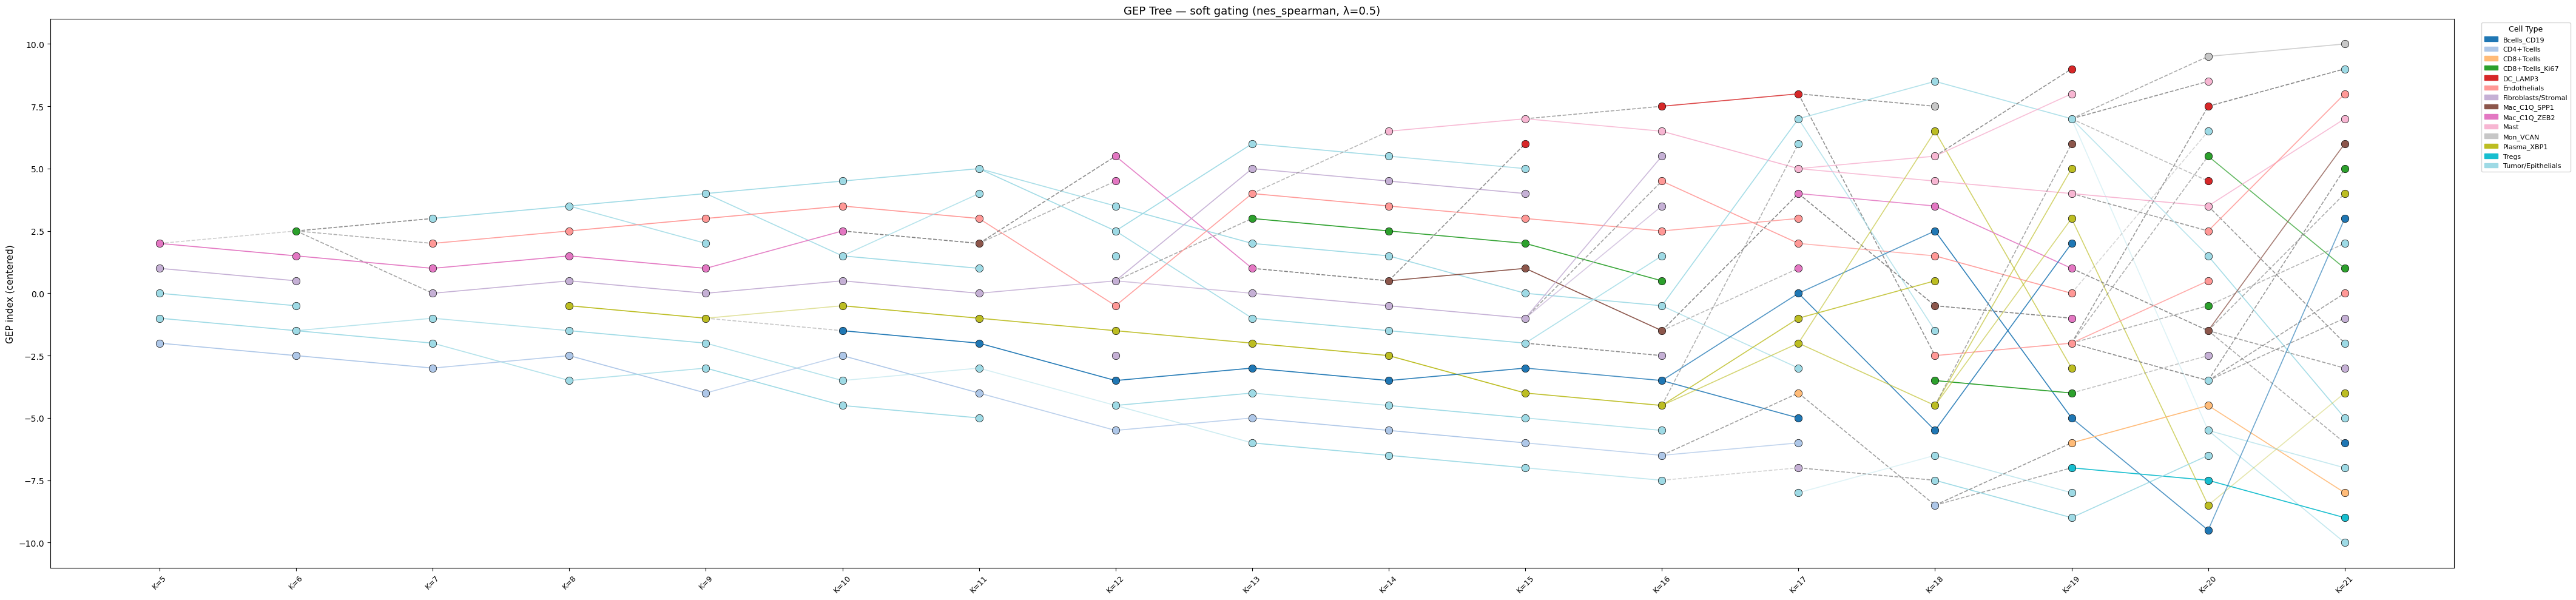

In [11]:
fig, ax = plt.subplots(figsize=(max(20, len(k_values) * 2.5), max(10, max(k_values) * 0.4)))

# Node positions: x = K index, y = GEP index within that K
node_pos = {}  # (k, gep) -> (x, y)
node_ct = {}   # (k, gep) -> cell type

for xi, k in enumerate(k_values):
    n_geps = len(all_nes[k])
    for yi, gep in enumerate(all_nes[k].index):
        # Center vertically
        y = yi - (n_geps - 1) / 2
        node_pos[(k, gep)] = (xi, y)
        node_ct[(k, gep)] = all_nes[k].loc[gep].idxmax()

# Draw edges
connected = edges_df[edges_df['parent_gep'].notna()]
for _, row in connected.iterrows():
    p_key = (row['k_parent'], row['parent_gep'])
    c_key = (row['k_child'], row['child_gep'])
    if p_key in node_pos and c_key in node_pos:
        px, py = node_pos[p_key]
        cx, cy = node_pos[c_key]
        alpha = min(1.0, max(0.15, row['gated_similarity']))
        color = 'gray' if not row['celltype_match'] else ct_colors.get(row['parent_celltype'], 'gray')
        ls = '-' if row['celltype_match'] else '--'
        ax.plot([px, cx], [py, cy], color=color, alpha=alpha, lw=1.2, ls=ls, zorder=1)

# Draw nodes
for (k, gep), (x, y) in node_pos.items():
    ct = node_ct[(k, gep)]
    color = ct_colors.get(ct, 'gray')
    ax.scatter(x, y, c=[color], s=80, edgecolors='black', linewidths=0.5, zorder=2)

# X-axis labels
ax.set_xticks(range(len(k_values)))
ax.set_xticklabels([f'K={k}' for k in k_values], fontsize=9, rotation=45)
ax.set_ylabel('GEP index (centered)', fontsize=11)
ax.set_title(f'GEP Tree — {GATING_MODE} gating ({SIMILARITY_METRIC}, λ={LAMBDA_KL})', fontsize=13)

# Legend
patches = [mpatches.Patch(color=ct_colors[ct], label=ct) for ct in all_celltypes]
ax.legend(handles=patches, loc='upper left', bbox_to_anchor=(1.01, 1.0),
          fontsize=8, title='Cell Type', title_fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "gep_tree_diagram.png"), dpi=150, bbox_inches='tight')
plt.show()

### 7c. Cell Type Composition Across K Values

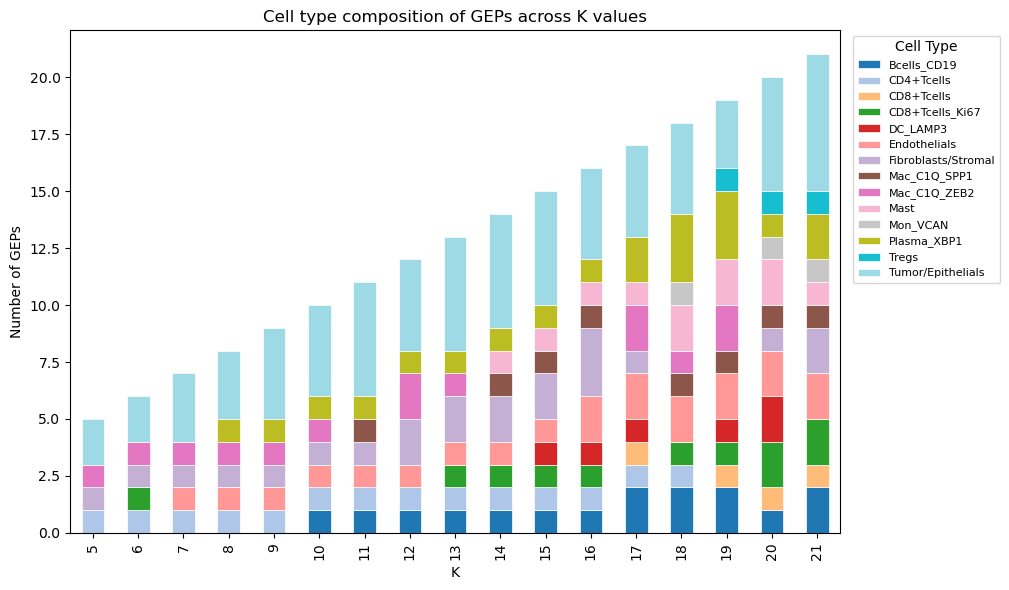

In [12]:
# For each K, count GEPs per cell type
composition = []
for k in k_values:
    for gep in all_nes[k].index:
        ct = all_nes[k].loc[gep].idxmax()
        composition.append({'K': k, 'CellType': ct})

comp_df = pd.DataFrame(composition)
comp_pivot = comp_df.groupby(['K', 'CellType']).size().unstack(fill_value=0)

# Stacked bar
fig, ax = plt.subplots(figsize=(max(10, len(k_values) * 0.6), 6))
comp_pivot.plot(kind='bar', stacked=True, ax=ax,
                color=[ct_colors.get(ct, 'gray') for ct in comp_pivot.columns],
                edgecolor='white', linewidth=0.5)
ax.set_xlabel('K')
ax.set_ylabel('Number of GEPs')
ax.set_title('Cell type composition of GEPs across K values')
ax.legend(bbox_to_anchor=(1.01, 1.0), fontsize=8, title='Cell Type')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "celltype_composition_by_k.png"), dpi=150, bbox_inches='tight')
plt.show()

## 8. Save pairwise results

In [13]:
details_path = os.path.join(OUTPUT_DIR, "pairwise_gated_similarities.csv")
details_df.to_csv(details_path, index=False)
print(f"Saved detailed pairwise similarities: {details_path}")
print(f"Shape: {details_df.shape}")
details_df.head()

Saved detailed pairwise similarities: celltype_gated_correlation_results/pairwise_gated_similarities.csv
Shape: (3040, 11)


,k_parent,k_child,parent_gep,child_gep,raw_sim,kl_div,penalty,gated_sim,parent_celltype,child_celltype,celltype_match
0,5,6,1,1,0.997546,0.000006,0.999997,0.997543,CD4+Tcells,CD4+Tcells,True
1,5,6,1,2,-0.368339,6.190087,0.045273,-0.016676,CD4+Tcells,Tumor/Epithelials,False
2,5,6,1,3,-0.364498,7.890995,0.019342,-0.007050,CD4+Tcells,Tumor/Epithelials,False
3,5,6,1,4,-0.612171,3.041018,0.218601,-0.133821,CD4+Tcells,Fibroblasts/Stromal,False
4,5,6,1,5,-0.559166,1.110421,0.573952,-0.320934,CD4+Tcells,Mac_C1Q_ZEB2,False


In [14]:
# Save per-transition similarity matrices
for (k_p, k_c), sim_mat in all_sim_matrices.items():
    path = os.path.join(OUTPUT_DIR, f"sim_matrix_k{k_p}_to_k{k_c}.csv")
    sim_mat.to_csv(path)

print(f"Saved {len(all_sim_matrices)} similarity matrices to {OUTPUT_DIR}/")

Saved 16 similarity matrices to celltype_gated_correlation_results/


## 9. Per-Transition Summary Table

In [15]:
transition_summary = []

for (k_p, k_c) in sorted(all_sim_matrices.keys()):
    subset = edges_df[(edges_df['k_parent'] == k_p) & (edges_df['k_child'] == k_c)]
    connected = subset[subset['parent_gep'].notna()]
    novel = subset[subset['parent_gep'].isna()]
    
    # Count splits (parents with >1 child)
    if len(connected) > 0:
        parent_counts = connected['parent_gep'].value_counts()
        n_splits = (parent_counts > 1).sum()
    else:
        n_splits = 0
    
    transition_summary.append({
        'transition': f'K={k_p}→{k_c}',
        'n_parents': len(all_nes[k_p]),
        'n_children': len(all_nes[k_c]),
        'n_edges': len(connected),
        'n_novel': len(novel),
        'n_splits': n_splits,
        'pct_same_ct': f"{100 * connected['celltype_match'].mean():.0f}%" if len(connected) > 0 else 'N/A',
        'mean_sim': f"{connected['gated_similarity'].mean():.3f}" if len(connected) > 0 else 'N/A'
    })

tsummary_df = pd.DataFrame(transition_summary)
tsummary_df.to_csv(os.path.join(OUTPUT_DIR, "transition_summary.csv"), index=False)
print(tsummary_df.to_string(index=False))

transition  n_parents  n_children  n_edges  n_novel  n_splits pct_same_ct mean_sim
     K=5→6          5           6        6        0         1         83%    0.894
     K=6→7          6           7        7        0         2         57%    0.842
     K=7→8          7           8        7        1         0        100%    0.894
     K=8→9          8           9        9        0         1        100%    0.958
    K=9→10          9          10       10        0         2         90%    0.813
   K=10→11         10          11       11        0         1         91%    0.922
   K=11→12         11          12       10        2         2         80%    0.827
   K=12→13         12          13       13        0         3         92%    0.862
   K=13→14         13          14       14        0         1         86%    0.933
   K=14→15         14          15       15        0         1         93%    0.955
   K=15→16         15          16       16        0         3         81%    0.832
   K